# 04 - Ingeniería de Atributos (Feature Engineering) con Pipelines de Scikit-Learn

**Proyecto:** Predicción de enfermedad cardíaca (`Heart---Data-Science-Project`)
**Etapa del ciclo de vida:** 4 - Feature Engineering
**Dataset:** `notebooks/1-data/corazon.csv`

---

## Objetivo

Dejar los datos crudos listos para entrenar un modelo de clasificación binaria que
determine si un paciente tiene o no enfermedad cardíaca (`disease`), construyendo
**todas** las transformaciones como `Pipeline` / `ColumnTransformer` de scikit-learn,
de forma que el mismo objeto pueda reutilizarse en entrenamiento, validación cruzada
y en producción (inferencia) sin reescribir una sola línea de preprocesamiento.

## Principio rector: evitar fuga de datos (*data leakage*)

Se distinguen dos tipos de operaciones:

| Tipo | Ejemplos | Dónde se hace | Motivo |
|---|---|---|---|
| **Dependen sólo de la fila** | eliminar duplicados, invalidar valores fuera de dominio, eliminar filas sin *target* | Antes del *split*, sobre el dataset completo | No aprenden ningún parámetro de los datos |
| **Aprenden parámetros del conjunto** | mediana de imputación, límites de atípicos, media/escala, bins de discretización, categorías del encoder | **Dentro del `Pipeline`**, ajustado sólo con `train` | Usar información de `test` inflaría artificialmente el desempeño |

## Contenido

1. Carga y diagnóstico de calidad de los datos crudos
2. **Limpieza de datos** (duplicados, valores inválidos, valores faltantes, atípicos)
3. Partición `train` / `test` estratificada
4. **Selección de atributos** (*feature selection*)
5. **Ingeniería de atributos**: transformadores personalizados, atributos derivados y discretización
6. **Escalado de atributos** (*feature scaling*)
7. **Encoding** de variables categóricas (nominales y ordinales)
8. Ensamblaje del `ColumnTransformer` y del pipeline completo
9. Validación del resultado y prueba de extremo a extremo con un modelo *baseline*
10. Persistencia de artefactos (pipeline serializado + datasets procesados)

## 1. Configuración e importación de librerías

In [1]:
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    KBinsDiscretizer,
    MinMaxScaler,
    OneHotEncoder,
    OrdinalEncoder,
    RobustScaler,
    StandardScaler,
)

warnings.filterwarnings("ignore")

# Todos los transformadores devuelven DataFrames de pandas: mantiene los nombres de
# las columnas a lo largo de todo el pipeline y hace el resultado auditable.
sklearn.set_config(transform_output="pandas")

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

SEMILLA = 42
PROPORCION_TEST = 0.2

print(f"pandas       {pd.__version__}")
print(f"numpy        {np.__version__}")
print(f"scikit-learn {sklearn.__version__}")

pandas       3.0.2
numpy        2.4.4
scikit-learn 1.8.0


### Rutas del proyecto

Se resuelve la raíz del repositorio buscando `pyproject.toml` hacia arriba, para que el
notebook funcione igual si se ejecuta desde su carpeta o desde la raíz del proyecto.

In [2]:
RUTA_RAIZ = Path.cwd().resolve()
while not (RUTA_RAIZ / "pyproject.toml").exists() and RUTA_RAIZ.parent != RUTA_RAIZ:
    RUTA_RAIZ = RUTA_RAIZ.parent

RUTA_CRUDOS = RUTA_RAIZ / "notebooks" / "1-data" / "corazon.csv"
RUTA_INTERMEDIA = RUTA_RAIZ / "data" / "02_intermediate"
RUTA_MODEL_INPUT = RUTA_RAIZ / "data" / "05_model_input"
RUTA_MODELOS = RUTA_RAIZ / "models"

for carpeta in (RUTA_INTERMEDIA, RUTA_MODEL_INPUT, RUTA_MODELOS):
    carpeta.mkdir(parents=True, exist_ok=True)

print(f"Raíz del proyecto : {RUTA_RAIZ}")
print(f"Datos crudos      : {RUTA_CRUDOS.relative_to(RUTA_RAIZ)}")

Raíz del proyecto : /home/claude/work/repo
Datos crudos      : notebooks/1-data/corazon.csv


## 2. Carga y diagnóstico de los datos crudos

Se cargan **todas** las columnas como texto (`dtype=str`). El archivo contiene valores
corruptos mezclados con los válidos, así que dejar que pandas infiera el tipo ocultaría
el problema (convertiría columnas numéricas en `object` silenciosamente).

In [3]:
datos_crudos = pd.read_csv(RUTA_CRUDOS, dtype=str, keep_default_na=True)

print(f"Registros : {datos_crudos.shape[0]:,}")
print(f"Atributos : {datos_crudos.shape[1]}")
datos_crudos.head()

Registros : 3,030
Atributos : 14


,age,sex,chest_pain,rest_bp,chol,fbs,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,disease
0,63,Male,typical,145,233,1,left ventricular hypertrophy,150,0,2.3,3,0.0,fixed,0
1,67,Male,asymptomatic,160,286,0,left ventricular hypertrophy,108,1,1.5,2,3.0,normal,1
2,67,Male,asymptomatic,120,229,0,left ventricular hypertrophy,129,1,2.6,2,2.0,reversable,1
3,37,Male,nonanginal,130,250,0,normal,187,0,3.5,3,0.0,normal,0
4,41,Female,nontypical,130,204,0,left ventricular hypertrophy,172,0,1.4,1,0.0,normal,0


### Diccionario de datos

| Atributo | Descripción | Tipo esperado |
|---|---|---|
| `age` | Edad en años | Numérico continuo |
| `sex` | `Male` / `Female` | Categórico nominal |
| `chest_pain` | Tipo de dolor torácico: `typical`, `atypical`, `nonanginal`, `asymptomatic` | Categórico nominal |
| `rest_bp` | Presión arterial en reposo (mm Hg) | Numérico continuo |
| `chol` | Colesterol sérico (mg/dl) | Numérico continuo |
| `fbs` | Glucemia en ayunas > 120 mg/dl (1 = sí, 0 = no) | Binario |
| `rest_ecg` | Electrocardiograma en reposo | Categórico nominal |
| `max_hr` | Frecuencia cardíaca máxima alcanzada | Numérico continuo |
| `exang` | Angina inducida por ejercicio (1 = sí, 0 = no) | Binario |
| `old_peak` | Depresión del segmento ST inducida por ejercicio | Numérico continuo |
| `slope` | Pendiente del segmento ST en ejercicio máximo (1 < 2 < 3) | Categórico **ordinal** |
| `ca` | Número de vasos principales coloreados por fluoroscopia (0 ≤ … ≤ 3) | Categórico **ordinal** |
| `thal` | Talasemia: `normal`, `fixed`, `reversable` | Categórico nominal |
| `disease` | **Target**: 1 = enfermedad, 0 = sano | Binario |

In [4]:
OBJETIVO = "disease"

# Dominios válidos declarados a partir del diccionario de datos: cualquier valor por
# fuera de estos conjuntos es un error de captura y se marcará como faltante.
DOMINIOS_CATEGORICOS: dict[str, set[str]] = {
    "sex": {"Male", "Female"},
    "chest_pain": {"typical", "atypical", "nontypical", "nonanginal", "asymptomatic"},
    "rest_ecg": {"normal", "left ventricular hypertrophy", "ST-T wave abnormality"},
    "thal": {"normal", "fixed", "reversable"},
}

# Rangos fisiológicamente plausibles: acotan errores de digitación en columnas numéricas.
RANGOS_NUMERICOS: dict[str, tuple[float, float]] = {
    "age": (18.0, 110.0),
    "rest_bp": (60.0, 260.0),
    "chol": (80.0, 700.0),
    "max_hr": (50.0, 250.0),
    "old_peak": (0.0, 10.0),
}

# Columnas discretas con un conjunto cerrado de códigos numéricos válidos.
CODIGOS_VALIDOS: dict[str, set[float]] = {
    "fbs": {0.0, 1.0},
    "exang": {0.0, 1.0},
    "slope": {1.0, 2.0, 3.0},
    "ca": {0.0, 1.0, 2.0, 3.0},
    OBJETIVO: {0.0, 1.0},
}

COLUMNAS_NUMERICAS = list(RANGOS_NUMERICOS)
COLUMNAS_CODIFICADAS = list(CODIGOS_VALIDOS)

### 2.1 Diagnóstico: ¿qué problemas tienen los datos?

In [5]:
def diagnosticar(df: pd.DataFrame, titulo: str) -> pd.DataFrame:
    """Construye una tabla resumen del estado de calidad de un DataFrame."""
    resumen = pd.DataFrame(
        {
            "tipo": df.dtypes.astype(str),
            "n_faltantes": df.isna().sum(),
            "%_faltantes": (df.isna().mean() * 100).round(2),
            "n_unicos": df.nunique(dropna=True),
        }
    )
    print(f"--- {titulo} ---")
    print(
        f"Filas: {len(df):,} | Columnas: {df.shape[1]} | Duplicados exactos: {df.duplicated().sum():,}"
    )
    return resumen


diagnosticar(datos_crudos, "Datos crudos")

--- Datos crudos ---
Filas: 3,030 | Columnas: 14 | Duplicados exactos: 2,462


,tipo,n_faltantes,%_faltantes,n_unicos
age,str,30,0.99,43
sex,str,61,2.01,5
chest_pain,str,83,2.74,7
rest_bp,str,81,2.67,52
chol,str,85,2.81,154
fbs,str,97,3.20,2
rest_ecg,str,193,6.37,8
max_hr,str,171,5.64,92
exang,str,151,4.98,4
old_peak,str,150,4.95,42


Se observan tres patologías simultáneas en el archivo:

1. **Duplicados masivos**: la mayoría de los registros están repetidos.
2. **Valores faltantes** en todas las columnas, incluido el *target*.
3. **Valores corruptos**: cadenas sin sentido (`'fggfds'`, `'afd'`) y números fuera de
   dominio (`'2345'` en `sex`) que pandas no reporta como faltantes.

Los valores corruptos son los más peligrosos porque son **invisibles** para
`isna()`. Se cuantifican explícitamente:

In [6]:
def contar_valores_invalidos(df: pd.DataFrame) -> pd.DataFrame:
    """Cuenta, por columna, los valores presentes que no pertenecen al dominio válido."""
    registros = []
    for columna, dominio in DOMINIOS_CATEGORICOS.items():
        presentes = df[columna].dropna().str.strip()
        invalidos = presentes[~presentes.isin(dominio)]
        registros.append((columna, "categórico", len(invalidos), sorted(invalidos.unique())[:4]))
    for columna in COLUMNAS_NUMERICAS:
        presentes = df[columna].dropna()
        numericos = pd.to_numeric(presentes, errors="coerce")
        limite_inf, limite_sup = RANGOS_NUMERICOS[columna]
        invalidos = presentes[numericos.isna() | ~numericos.between(limite_inf, limite_sup)]
        registros.append((columna, "numérico", len(invalidos), sorted(invalidos.unique())[:4]))
    for columna in COLUMNAS_CODIFICADAS:
        presentes = df[columna].dropna()
        numericos = pd.to_numeric(presentes, errors="coerce")
        invalidos = presentes[~numericos.isin(CODIGOS_VALIDOS[columna])]
        registros.append((columna, "código", len(invalidos), sorted(invalidos.unique())[:4]))
    return pd.DataFrame(
        registros, columns=["atributo", "tipo", "n_invalidos", "ejemplos"]
    ).sort_values("n_invalidos", ascending=False, ignore_index=True)


contar_valores_invalidos(datos_crudos)

,atributo,tipo,n_invalidos,ejemplos
0,rest_ecg,categórico,5,"[3563, 36653, 435647, 5653]"
1,disease,código,5,"[fsdg, fsg, g, gsfdg]"
2,thal,categórico,4,"[365635463, 53646, 56, 87654]"
3,chest_pain,categórico,3,"[2345, 2435, 3456]"
4,sex,categórico,3,"[2345, 45, 765]"
5,age,numérico,2,"[fggfds, sdg]"
6,rest_bp,numérico,2,"[fsgh, wety]"
7,chol,numérico,2,"[sfdywe, wtey]"
8,exang,código,2,"[adfs, f]"
9,old_peak,numérico,2,"[afd, asd]"


## 3. Limpieza de datos

Estas operaciones **no aprenden parámetros** de los datos (no calculan medias, umbrales
ni categorías): dependen únicamente del diccionario de datos y de cada fila por
separado. Por eso pueden ejecutarse sobre el dataset completo antes de la partición
`train`/`test` sin producir fuga de datos.

Orden de las operaciones:

1. Normalizar el texto (espacios sobrantes, mayúsculas).
2. Convertir a numérico y marcar como faltante todo valor fuera de dominio o de rango.
3. Eliminar filas sin *target* (no aportan al aprendizaje supervisado).
4. Eliminar filas con demasiada información ausente.
5. **Eliminar registros duplicados exactos.**
6. **Eliminar duplicados parciales**: al anular los valores corruptos, un mismo paciente
   aparece varias veces con distinto patrón de celdas vacías, de modo que `drop_duplicates()`
   ya no las reconoce como iguales. Se elimina toda fila cuyos valores presentes coincidan
   con los de otra fila más completa (relación de *subsunción*). Es un paso crítico: si dos
   copias del mismo paciente caen una en `train` y otra en `test`, la evaluación quedaría
   contaminada.

In [7]:
UMBRAL_FALTANTES_FILA = 0.5


def normalizar_texto(df: pd.DataFrame) -> pd.DataFrame:
    """Quita espacios sobrantes y unifica el espaciado interno de las columnas de texto."""
    df = df.copy()
    for columna in DOMINIOS_CATEGORICOS:
        df[columna] = df[columna].str.strip().str.replace(r"\s+", " ", regex=True)
    return df


def tipificar_y_validar(df: pd.DataFrame) -> pd.DataFrame:
    """Convierte cada columna a su tipo correcto y anula los valores fuera de dominio."""
    df = df.copy()
    for columna, dominio in DOMINIOS_CATEGORICOS.items():
        df[columna] = df[columna].where(df[columna].isin(dominio))
    for columna, (limite_inf, limite_sup) in RANGOS_NUMERICOS.items():
        valores = pd.to_numeric(df[columna], errors="coerce")
        df[columna] = valores.where(valores.between(limite_inf, limite_sup))
    for columna, codigos in CODIGOS_VALIDOS.items():
        valores = pd.to_numeric(df[columna], errors="coerce")
        df[columna] = valores.where(valores.isin(codigos))
    return df


def eliminar_duplicados_parciales(df: pd.DataFrame) -> pd.DataFrame:
    """Elimina las filas cuyos valores presentes están contenidos en otra fila más completa.

    Dos registros del mismo paciente pueden diferir sólo en qué celdas quedaron vacías
    tras invalidar los valores corruptos; `drop_duplicates()` no los detecta. Se recorren
    las filas de la más completa a la menos completa y se descarta toda fila "subsumida".
    """
    orden = df.notna().sum(axis=1).sort_values(ascending=False, kind="stable").index
    ordenado = df.loc[orden]
    valores = ordenado.to_numpy(dtype=object)
    presencia = ordenado.notna().to_numpy()

    conservadas: list[int] = []
    for i in range(len(valores)):
        columnas_presentes = np.flatnonzero(presencia[i])
        subsumida = any(
            bool((valores[j][columnas_presentes] == valores[i][columnas_presentes]).all())
            for j in conservadas
        )
        if not subsumida:
            conservadas.append(i)

    indices = ordenado.index[conservadas]
    return df.loc[df.index.isin(indices)].reset_index(drop=True)


def limpiar_datos(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica la limpieza completa y devuelve el dataset listo para particionar."""
    limpio = normalizar_texto(df)
    limpio = tipificar_y_validar(limpio)
    limpio = limpio.dropna(subset=[OBJETIVO])
    proporcion_faltante = limpio.drop(columns=[OBJETIVO]).isna().mean(axis=1)
    limpio = limpio[proporcion_faltante <= UMBRAL_FALTANTES_FILA]
    limpio = limpio.drop_duplicates(ignore_index=True)
    limpio = eliminar_duplicados_parciales(limpio)
    limpio[OBJETIVO] = limpio[OBJETIVO].astype("int8")
    return limpio


datos_limpios = limpiar_datos(datos_crudos)
diagnosticar(datos_limpios, "Datos limpios")

--- Datos limpios ---
Filas: 303 | Columnas: 14 | Duplicados exactos: 0


,tipo,n_faltantes,%_faltantes,n_unicos
age,float64,0,0.00,41
sex,str,0,0.00,2
chest_pain,str,0,0.00,4
rest_bp,float64,0,0.00,50
chol,float64,0,0.00,152
fbs,float64,0,0.00,2
rest_ecg,str,0,0.00,3
max_hr,float64,0,0.00,91
exang,float64,0,0.00,2
old_peak,float64,0,0.00,40


### 3.1 Trazabilidad de la limpieza

Se documenta cuántos registros elimina cada paso, para poder justificar la reducción
del dataset ante una revisión.

In [8]:
def trazar_limpieza(df: pd.DataFrame) -> pd.DataFrame:
    """Registra el número de filas después de cada etapa de la limpieza."""
    pasos: list[tuple[str, int]] = [("0. Datos crudos", len(df))]
    paso = normalizar_texto(df)
    paso = tipificar_y_validar(paso)
    pasos.append(("1. Tipificación y validación de dominio", len(paso)))
    paso = paso.dropna(subset=[OBJETIVO])
    pasos.append(("2. Sin target faltante", len(paso)))
    proporcion = paso.drop(columns=[OBJETIVO]).isna().mean(axis=1)
    paso = paso[proporcion <= UMBRAL_FALTANTES_FILA]
    pasos.append((f"3. Filas con <= {UMBRAL_FALTANTES_FILA:.0%} de faltantes", len(paso)))
    paso = paso.drop_duplicates(ignore_index=True)
    pasos.append(("4. Sin duplicados exactos", len(paso)))
    paso = eliminar_duplicados_parciales(paso)
    pasos.append(("5. Sin duplicados parciales", len(paso)))

    traza = pd.DataFrame(pasos, columns=["paso", "filas"])
    traza["eliminadas"] = -traza["filas"].diff().fillna(0).astype(int)
    traza["%_restante"] = (traza["filas"] / len(df) * 100).round(1)
    return traza


trazar_limpieza(datos_crudos)

,paso,filas,eliminadas,%_restante
0,0. Datos crudos,3030,0,100.0
1,1. Tipificación y validación de dominio,3030,0,100.0
2,2. Sin target faltante,2919,111,96.3
3,3. Filas con <= 50% de faltantes,2841,78,93.8
4,4. Sin duplicados exactos,402,2439,13.3
5,5. Sin duplicados parciales,303,99,10.0


### 3.2 Valores faltantes remanentes

Tras la limpieza quedan faltantes legítimos (celdas realmente vacías o anuladas por
estar fuera de dominio). **No se eliminan aquí**: se imputan dentro del pipeline, con
estadísticos calculados exclusivamente sobre `train`.

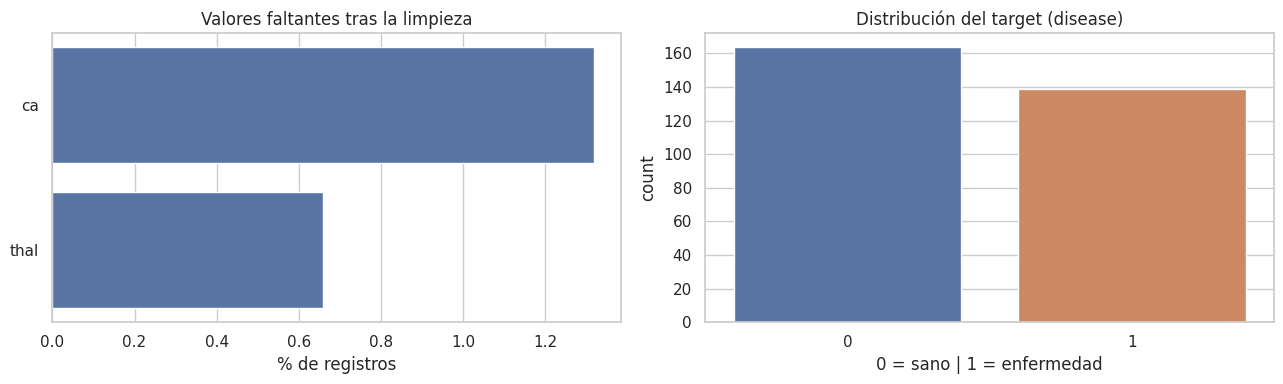

disease
0    0.541
1    0.459


In [9]:
faltantes = datos_limpios.isna().mean().mul(100).round(2).sort_values(ascending=False)
faltantes = faltantes[faltantes > 0]

fig, ejes = plt.subplots(1, 2, figsize=(13, 4))
if len(faltantes) > 0:
    sns.barplot(x=faltantes.to_numpy(), y=faltantes.index.to_numpy(), ax=ejes[0], color="#4C72B0")
ejes[0].set_title("Valores faltantes tras la limpieza")
ejes[0].set_xlabel("% de registros")

sns.countplot(x=datos_limpios[OBJETIVO], ax=ejes[1], hue=datos_limpios[OBJETIVO], legend=False)
ejes[1].set_title("Distribución del target (disease)")
ejes[1].set_xlabel("0 = sano | 1 = enfermedad")
plt.tight_layout()
plt.show()

print(datos_limpios[OBJETIVO].value_counts(normalize=True).round(3).to_string())

### 3.3 Valores atípicos: estrategia adoptada

El dataset es pequeño (unos pocos cientos de pacientes) y los valores extremos de
`chol`, `rest_bp` u `old_peak` corresponden a **pacientes reales de alto riesgo**:
eliminarlos borraría justamente la señal clínica más informativa.

Estrategia elegida — **marcar y acotar, no eliminar**:

- **Marcar**: se generan atributos binarios `<columna>_atipico` que le indican al modelo
  que ese paciente tenía un valor extremo (información clínicamente relevante).
- **Acotar** (*winsorizing*): los valores se recortan al rango `[Q1 − 1.5·IQR, Q3 + 1.5·IQR]`
  para que no dominen el escalado ni los modelos sensibles a la escala.
- Ambas operaciones **aprenden los límites de `train`** y por eso viven dentro del pipeline.

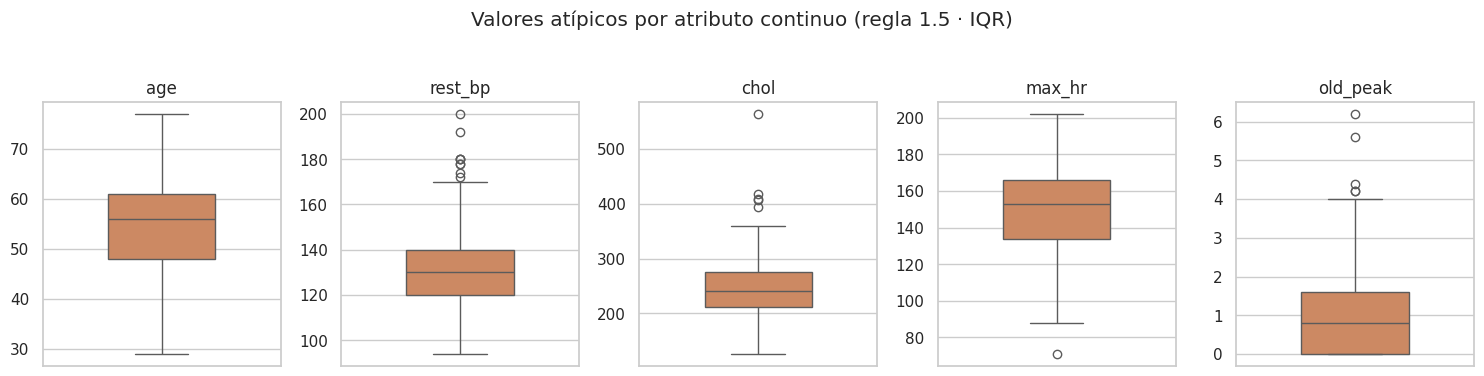

,atributo,limite_inf,limite_sup,n_atipicos,%
0,age,28.50,80.50,0,0.00
1,rest_bp,90.00,170.00,9,2.97
2,chol,115.00,371.00,5,1.65
3,max_hr,84.75,214.75,1,0.33
4,old_peak,-2.40,4.00,5,1.65


In [10]:
columnas_continuas = COLUMNAS_NUMERICAS
fig, ejes = plt.subplots(1, len(columnas_continuas), figsize=(15, 3.6))
for eje, columna in zip(ejes, columnas_continuas):
    sns.boxplot(y=datos_limpios[columna], ax=eje, color="#DD8452", width=0.45)
    eje.set_title(columna)
    eje.set_ylabel("")
fig.suptitle("Valores atípicos por atributo continuo (regla 1.5 · IQR)", y=1.04)
plt.tight_layout()
plt.show()


def resumen_atipicos(df: pd.DataFrame, columnas: list[str], factor: float = 1.5) -> pd.DataFrame:
    """Cuantifica los valores atípicos de cada columna según la regla del rango intercuartílico."""
    filas = []
    for columna in columnas:
        q1, q3 = df[columna].quantile([0.25, 0.75])
        rango = q3 - q1
        inferior, superior = q1 - factor * rango, q3 + factor * rango
        atipicos = df[columna][(df[columna] < inferior) | (df[columna] > superior)]
        filas.append(
            (
                columna,
                round(inferior, 2),
                round(superior, 2),
                len(atipicos),
                round(len(atipicos) / df[columna].notna().sum() * 100, 2),
            )
        )
    return pd.DataFrame(filas, columns=["atributo", "limite_inf", "limite_sup", "n_atipicos", "%"])


resumen_atipicos(datos_limpios, columnas_continuas)

### 3.4 Persistencia del dataset limpio

El dataset limpio se guarda en `data/02_intermediate` siguiendo la convención de capas
del proyecto (raw → intermediate → primary → feature → model_input).

In [11]:
ARCHIVO_LIMPIO = RUTA_INTERMEDIA / "corazon_limpio.parquet"
datos_limpios.to_parquet(ARCHIVO_LIMPIO, index=False)
print(
    f"Guardado: {ARCHIVO_LIMPIO.relative_to(RUTA_RAIZ)}  ({datos_limpios.shape[0]} x {datos_limpios.shape[1]})"
)

Guardado: data/02_intermediate/corazon_limpio.parquet  (303 x 14)


## 4. Partición `train` / `test`

Se parte **antes** de ajustar cualquier transformador. La partición es estratificada
por el *target* para conservar la proporción de clases en ambos conjuntos.

In [12]:
X = datos_limpios.drop(columns=[OBJETIVO])
y = datos_limpios[OBJETIVO]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=PROPORCION_TEST, stratify=y, random_state=SEMILLA
)

print(f"train : {X_train.shape[0]:>4} filas  ({y_train.mean():.1%} positivos)")
print(f"test  : {X_test.shape[0]:>4} filas  ({y_test.mean():.1%} positivos)")

train :  242 filas  (45.9% positivos)
test  :   61 filas  (45.9% positivos)


## 5. Selección de atributos (*Feature Selection*)

Criterio de descarte, evaluado **sólo sobre `train`**:

1. **Cuasi-constantes**: un único valor concentra más del 95 % de los registros — su
   varianza es casi nula y no permite discriminar entre pacientes.
2. **Sin información sobre el target**: información mutua prácticamente nula respecto
   de `disease`.

Tres precauciones para no descartar de más:

- La información mutua se estima con `mutual_info_classif`, que usa un estimador basado
  en vecinos más cercanos con componente aleatoria. Sobre ~240 filas una sola corrida es
  ruidosa, así que se **promedian 15 repeticiones** y se declara explícitamente qué
  atributos son discretos.
- El umbral es **deliberadamente conservador**: la información mutua es *univariada*, y
  un atributo poco informativo por sí solo puede aportar en combinación con otros.
- Los atributos que alimentan los atributos derivados de la sección 6.1 quedan
  **protegidos** del descarte automático, para que el pipeline no se rompa al re-ejecutar
  el notebook con otra muestra de datos.

La información mutua se estima sobre una copia imputada temporal (sólo para el
diagnóstico); el pipeline definitivo hace su propia imputación.

In [13]:
UMBRAL_CUASI_CONSTANTE = 0.95
UMBRAL_INFO_MUTUA = 0.002
REPETICIONES_INFO_MUTUA = 15
COLUMNAS_PROTEGIDAS = {"age", "rest_bp", "chol", "max_hr", "old_peak"}

X_train_diagnostico = X_train.copy()
for columna in X_train_diagnostico.columns:
    serie = X_train_diagnostico[columna]
    if pd.api.types.is_numeric_dtype(serie):
        X_train_diagnostico[columna] = serie.fillna(serie.median())
    else:
        X_train_diagnostico[columna] = (
            serie.fillna(serie.mode(dropna=True).iloc[0]).astype("category").cat.codes
        )

atributos_discretos = [X_train_diagnostico[c].nunique() <= 5 for c in X_train_diagnostico.columns]
info_mutua = pd.Series(
    np.mean(
        [
            mutual_info_classif(
                X_train_diagnostico,
                y_train,
                discrete_features=atributos_discretos,
                random_state=semilla,
            )
            for semilla in range(REPETICIONES_INFO_MUTUA)
        ],
        axis=0,
    ),
    index=X_train_diagnostico.columns,
).sort_values(ascending=False)

frecuencia_dominante = X_train.apply(lambda s: s.value_counts(normalize=True, dropna=True).max())

tabla_seleccion = pd.DataFrame(
    {
        "info_mutua": info_mutua.round(4),
        "frec_valor_dominante": frecuencia_dominante.round(3),
    }
).sort_values("info_mutua", ascending=False)
tabla_seleccion["protegido"] = tabla_seleccion.index.isin(COLUMNAS_PROTEGIDAS)
tabla_seleccion["descartar"] = (
    (tabla_seleccion["info_mutua"] < UMBRAL_INFO_MUTUA)
    | (tabla_seleccion["frec_valor_dominante"] > UMBRAL_CUASI_CONSTANTE)
) & ~tabla_seleccion["protegido"]
tabla_seleccion

,info_mutua,frec_valor_dominante,protegido,descartar
thal,0.1560,0.560,False,False
chest_pain,0.1272,0.483,False,False
ca,0.1161,0.610,False,False
exang,0.0911,0.674,False,False
max_hr,0.0833,0.041,True,False
old_peak,0.0778,0.318,True,False
slope,0.0706,0.479,False,False
chol,0.0586,0.025,True,False
sex,0.0496,0.682,False,False
rest_ecg,0.0155,0.508,False,False


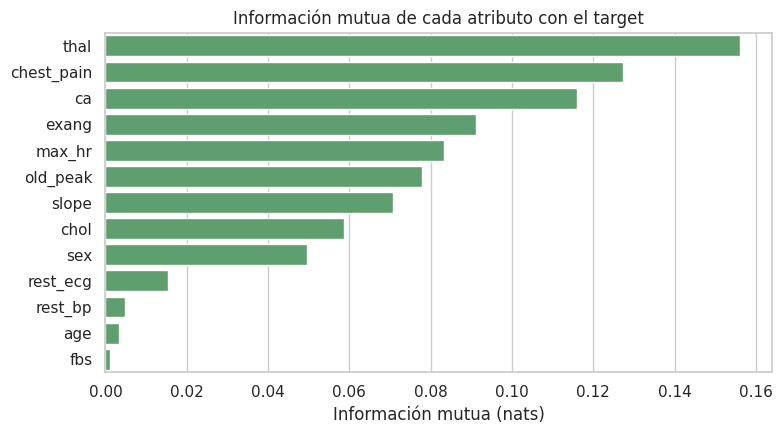

Descartados  (1): ['fbs']
Seleccionados (12): ['age', 'sex', 'chest_pain', 'rest_bp', 'chol', 'rest_ecg', 'max_hr', 'exang', 'old_peak', 'slope', 'ca', 'thal']


In [14]:
fig, eje = plt.subplots(figsize=(8, 4.5))
sns.barplot(x=info_mutua.to_numpy(), y=info_mutua.index.to_numpy(), ax=eje, color="#55A868")
eje.set_title("Información mutua de cada atributo con el target")
eje.set_xlabel("Información mutua (nats)")
plt.tight_layout()
plt.show()

ATRIBUTOS_DESCARTADOS = tabla_seleccion.index[tabla_seleccion["descartar"]].tolist()
ATRIBUTOS_SELECCIONADOS = [c for c in X_train.columns if c not in ATRIBUTOS_DESCARTADOS]

print(f"Descartados  ({len(ATRIBUTOS_DESCARTADOS)}): {ATRIBUTOS_DESCARTADOS or 'ninguno'}")
print(f"Seleccionados ({len(ATRIBUTOS_SELECCIONADOS)}): {ATRIBUTOS_SELECCIONADOS}")

### 5.1 Duplicados generados por la selección

Al reducir el número de columnas pueden aparecer filas idénticas que antes se
distinguían únicamente por un atributo descartado. Se verifica explícitamente.

In [15]:
duplicados_tras_seleccion = X_train[ATRIBUTOS_SELECCIONADOS].duplicated().sum()
print(f"Duplicados en train tras la selección de atributos: {duplicados_tras_seleccion}")

if duplicados_tras_seleccion > 0:
    mascara = ~X_train[ATRIBUTOS_SELECCIONADOS].duplicated()
    X_train, y_train = X_train[mascara], y_train[mascara]
    print(f"Eliminados. train queda con {len(X_train)} filas.")

Duplicados en train tras la selección de atributos: 0


> La deduplicación se aplica **sólo a `train`**: `test` debe conservarse intacto para
> que la evaluación refleje la distribución real de los datos.

## 6. Ingeniería de atributos: transformadores personalizados

Scikit-learn permite extender su API implementando `fit` / `transform` sobre
`BaseEstimator` + `TransformerMixin`. Así los transformadores propios se componen con
los nativos, participan de `GridSearchCV` y se serializan junto con el pipeline.

Se implementan dos, con una clase base común que aprende los límites del rango
intercuartílico **sobre `train`**:

- `RecortadorAtipicos`: acota (winsoriza) los valores extremos.
- `MarcadorAtipicos`: genera atributos binarios que señalan qué valores eran extremos.

In [16]:
class BaseIQR(BaseEstimator, TransformerMixin):
    """Clase base: aprende los límites de Tukey (Q1 - k·IQR, Q3 + k·IQR) por columna."""

    def __init__(self, factor: float = 1.5) -> None:
        self.factor = factor

    def fit(self, X: pd.DataFrame, y: pd.Series | None = None) -> "BaseIQR":
        del y  # no se usa: la regla es no supervisada
        q1 = X.quantile(0.25)
        q3 = X.quantile(0.75)
        rango_intercuartil = q3 - q1
        self.limite_inferior_ = q1 - self.factor * rango_intercuartil
        self.limite_superior_ = q3 + self.factor * rango_intercuartil
        self.feature_names_in_ = np.asarray(X.columns, dtype=object)
        self.n_features_in_ = X.shape[1]
        return self


class RecortadorAtipicos(BaseIQR):
    """Recorta los valores extremos al rango aprendido en el conjunto de entrenamiento."""

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        return X.clip(lower=self.limite_inferior_, upper=self.limite_superior_, axis=1)

    def get_feature_names_out(self, input_features=None) -> np.ndarray:
        del input_features
        return self.feature_names_in_


class MarcadorAtipicos(BaseIQR):
    """Crea un indicador binario por columna: 1 si el valor original era atípico."""

    def transform(self, X: pd.DataFrame) -> pd.DataFrame:
        fuera_de_rango = X.lt(self.limite_inferior_) | X.gt(self.limite_superior_)
        marcas = fuera_de_rango.astype("float64")
        marcas.columns = [f"{columna}_atipico" for columna in X.columns]
        return marcas

    def get_feature_names_out(self, input_features=None) -> np.ndarray:
        del input_features
        return np.asarray([f"{c}_atipico" for c in self.feature_names_in_], dtype=object)

### 6.1 Atributos derivados

Se añaden atributos con sentido clínico y transformaciones matemáticas que suelen
linealizar relaciones sesgadas:

| Atributo nuevo | Fórmula | Justificación |
|---|---|---|
| `fc_maxima_teorica` | `220 − age` | Frecuencia cardíaca máxima esperada por edad |
| `reserva_cardiaca` | `max_hr / (220 − age)` | Qué fracción de su máximo teórico alcanzó el paciente; normaliza `max_hr` por edad |
| `chol_rel_edad` | `chol / age` | Colesterol relativo a la edad |
| `carga_presion` | `rest_bp / max_hr` | Relación presión–frecuencia, proxy de carga cardíaca |
| `log_old_peak` | `log(1 + old_peak)` | `old_peak` tiene fuerte asimetría a la derecha |
| `sqrt_chol` | `√chol` | Reduce la asimetría de `chol` |
| `st_deprimido` | `old_peak > 0` | Presencia (no magnitud) de depresión del ST |

Se implementan con un `FunctionTransformer`, que es la forma canónica de incorporar una
función sin estado a un pipeline de scikit-learn.

In [17]:
ATRIBUTOS_DERIVADOS = [
    "fc_maxima_teorica",
    "reserva_cardiaca",
    "chol_rel_edad",
    "carga_presion",
    "log_old_peak",
    "sqrt_chol",
    "st_deprimido",
]


def agregar_atributos_derivados(X: pd.DataFrame) -> pd.DataFrame:
    """Añade atributos derivados. Propaga los faltantes para que los impute el pipeline."""
    # Se reinicia el índice: `KBinsDiscretizer` devuelve un índice posicional, y
    # `ColumnTransformer` exige que todas las ramas compartan el mismo índice al concatenar.
    X = X.copy().reset_index(drop=True)
    X["fc_maxima_teorica"] = 220.0 - X["age"]
    X["reserva_cardiaca"] = X["max_hr"] / X["fc_maxima_teorica"]
    X["chol_rel_edad"] = X["chol"] / X["age"]
    X["carga_presion"] = X["rest_bp"] / X["max_hr"]
    X["log_old_peak"] = np.log1p(X["old_peak"])
    X["sqrt_chol"] = np.sqrt(X["chol"])
    X["st_deprimido"] = np.where(
        X["old_peak"].isna(), np.nan, (X["old_peak"] > 0).astype("float64")
    )
    return X


def nombres_derivados(_transformador, input_features) -> np.ndarray:
    """`get_feature_names_out` del FunctionTransformer: originales + derivados."""
    return np.asarray([*list(input_features), *ATRIBUTOS_DERIVADOS], dtype=object)


generador_atributos = FunctionTransformer(
    agregar_atributos_derivados,
    feature_names_out=nombres_derivados,
    validate=False,
)

# Verificación rápida sobre una muestra
generador_atributos.fit_transform(X_train[ATRIBUTOS_SELECCIONADOS]).head(3)

,age,sex,chest_pain,rest_bp,chol,rest_ecg,max_hr,exang,old_peak,slope,ca,thal,fc_maxima_teorica,reserva_cardiaca,chol_rel_edad,carga_presion,log_old_peak,sqrt_chol,st_deprimido
0,48.0,Male,asymptomatic,124.0,274.0,left ventricular hypertrophy,166.0,0.0,0.5,2.0,0.0,reversable,172.0,0.965116,5.708333,0.746988,0.405465,16.552945,1.0
1,55.0,Male,nontypical,130.0,262.0,normal,155.0,0.0,0.0,1.0,0.0,normal,165.0,0.939394,4.763636,0.838710,0.000000,16.186414,0.0
2,54.0,Female,nontypical,132.0,288.0,left ventricular hypertrophy,159.0,1.0,0.0,1.0,1.0,normal,166.0,0.957831,5.333333,0.830189,0.000000,16.970563,0.0


## 7. Definición de los grupos de columnas

Cada grupo recibe un tratamiento distinto. Nótese que algunas columnas aparecen en
**dos** grupos a la vez (`age`, `chol`, `max_hr`): se usan tanto en su versión continua
escalada como en su versión discretizada, y `ColumnTransformer` lo permite.

In [18]:
CONTINUAS = [
    "age",
    "rest_bp",
    "chol",
    "max_hr",
    "old_peak",
    "fc_maxima_teorica",
    "reserva_cardiaca",
    "chol_rel_edad",
    "carga_presion",
    "log_old_peak",
    "sqrt_chol",
]
A_DISCRETIZAR = ["age", "chol", "max_hr"]
MARCAR_ATIPICOS = ["rest_bp", "chol", "old_peak"]
NOMINALES = ["sex", "chest_pain", "rest_ecg", "thal"]
ORDINALES = ["slope", "ca"]
BINARIAS = ["fbs", "exang", "st_deprimido"]

# Se filtran las columnas que la selección de atributos haya descartado.
disponibles = set(ATRIBUTOS_SELECCIONADOS) | set(ATRIBUTOS_DERIVADOS)
CONTINUAS = [c for c in CONTINUAS if c in disponibles]
A_DISCRETIZAR = [c for c in A_DISCRETIZAR if c in disponibles]
MARCAR_ATIPICOS = [c for c in MARCAR_ATIPICOS if c in disponibles]
NOMINALES = [c for c in NOMINALES if c in disponibles]
ORDINALES = [c for c in ORDINALES if c in disponibles]
BINARIAS = [c for c in BINARIAS if c in disponibles]

for nombre, grupo in [
    ("continuas", CONTINUAS),
    ("a discretizar", A_DISCRETIZAR),
    ("marcar atípicos", MARCAR_ATIPICOS),
    ("nominales", NOMINALES),
    ("ordinales", ORDINALES),
    ("binarias", BINARIAS),
]:
    print(f"{nombre:>16}: {grupo}")

       continuas: ['age', 'rest_bp', 'chol', 'max_hr', 'old_peak', 'fc_maxima_teorica', 'reserva_cardiaca', 'chol_rel_edad', 'carga_presion', 'log_old_peak', 'sqrt_chol']
   a discretizar: ['age', 'chol', 'max_hr']
 marcar atípicos: ['rest_bp', 'chol', 'old_peak']
       nominales: ['sex', 'chest_pain', 'rest_ecg', 'thal']
       ordinales: ['slope', 'ca']
        binarias: ['exang', 'st_deprimido']


## 8. Escalado de atributos: elección del escalador

Se comparan las tres estrategias más habituales sobre `chol` (la variable con más
atípicos) para justificar la elección:

- `StandardScaler` — media 0, desviación 1. Sensible a los atípicos.
- `MinMaxScaler` — comprime al rango [0, 1]. Muy sensible a los atípicos.
- `RobustScaler` — centra en la mediana y escala por el IQR. **Robusto a los atípicos.**

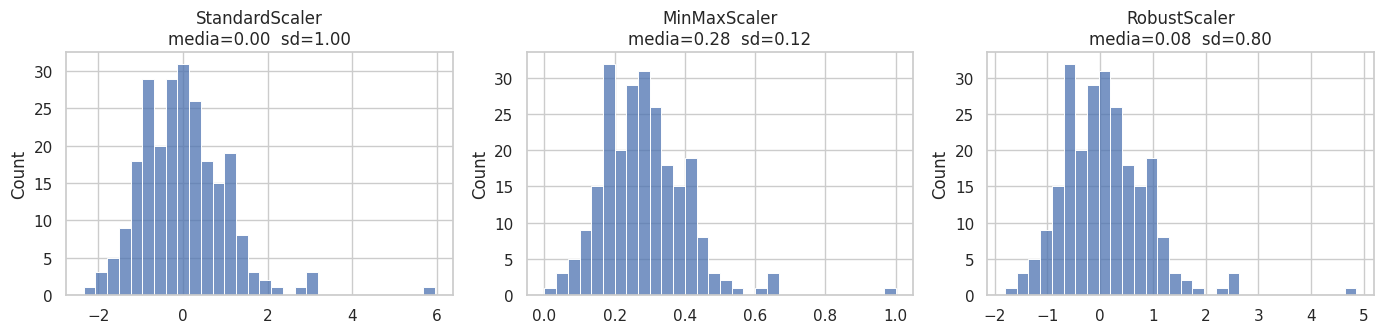

,count,mean,std,min,25%,50%,75%,max
StandardScaler,242.0,0.000,1.002,-2.348,-0.717,-0.101,0.529,5.957
MinMaxScaler,242.0,0.283,0.121,0.000,0.196,0.271,0.346,1.000
RobustScaler,242.0,0.081,0.804,-1.802,-0.494,0.000,0.506,4.859


In [19]:
muestra = X_train[["chol"]].fillna(X_train["chol"].median())
comparacion = pd.DataFrame(
    {
        "StandardScaler": StandardScaler().fit_transform(muestra)["chol"],
        "MinMaxScaler": MinMaxScaler().fit_transform(muestra)["chol"],
        "RobustScaler": RobustScaler().fit_transform(muestra)["chol"],
    }
)

fig, ejes = plt.subplots(1, 3, figsize=(14, 3.5))
for eje, columna in zip(ejes, comparacion.columns):
    sns.histplot(comparacion[columna], ax=eje, bins=30, color="#4C72B0")
    eje.set_title(
        f"{columna}\nmedia={comparacion[columna].mean():.2f}  sd={comparacion[columna].std():.2f}"
    )
    eje.set_xlabel("")
plt.tight_layout()
plt.show()

comparacion.describe().T.round(3)

**Decisión:** se usa `RobustScaler`, coherente con la estrategia de conservar los
pacientes extremos: aunque los valores se acotan previamente con `RecortadorAtipicos`,
centrar en la mediana y escalar por el IQR evita que la cola derecha de `chol` y
`old_peak` distorsione la escala del resto de los atributos.

## 9. Construcción de los sub-pipelines

Un `Pipeline` por tipo de dato. El orden dentro de cada uno importa: primero se imputa
(para que los pasos siguientes no reciban `NaN`), luego se trata el atípico y por
último se escala o codifica.

In [20]:
# 9.1 Continuas: imputar → acotar atípicos → escalar de forma robusta
pipeline_continuas = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="median")),
        ("recorte_atipicos", RecortadorAtipicos(factor=1.5)),
        ("escalado", RobustScaler()),
    ]
)

# 9.2 Discretización: imputar → dividir en cuartiles → one-hot de los intervalos
pipeline_discretizacion = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="median")),
        (
            "discretizacion",
            KBinsDiscretizer(n_bins=4, encode="onehot-dense", strategy="quantile"),
        ),
    ]
)

# 9.3 Marcado de atípicos: imputar → generar indicadores binarios
pipeline_marcas = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="median")),
        ("marcado_atipicos", MarcadorAtipicos(factor=1.5)),
    ]
)

# 9.4 Categóricas nominales: imputar con la moda → One-Hot Encoding
pipeline_nominales = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        (
            "codificacion",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                sparse_output=False,
                min_frequency=0.01,
            ),
        ),
    ]
)

# 9.5 Categóricas ordinales: imputar con la moda → Ordinal Encoding con el orden explícito
pipeline_ordinales = Pipeline(
    steps=[
        ("imputacion", SimpleImputer(strategy="most_frequent")),
        (
            "codificacion",
            OrdinalEncoder(
                categories=[sorted(CODIGOS_VALIDOS[c]) for c in ORDINALES],
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

# 9.6 Binarias: sólo imputar con la moda (ya están codificadas 0/1)
pipeline_binarias = Pipeline(steps=[("imputacion", SimpleImputer(strategy="most_frequent"))])

pipeline_continuas

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputacion', ...), ('recorte_atipicos', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite 

### Nota sobre el *encoding*

- **One-Hot** para las nominales: `sex`, `chest_pain`, `rest_ecg`, `thal` no tienen orden
  intrínseco; asignarles códigos enteros introduciría una relación de magnitud falsa.
  `handle_unknown="infrequent_if_exist"` permite que en producción lleguen categorías no
  vistas sin que el pipeline falle.
- **Ordinal** para `slope` y `ca`: sí tienen orden natural (`1 < 2 < 3` y `0 ≤ … ≤ 3`),
  y se declara explícitamente con `categories=` en lugar de dejarlo al azar del `auto`.

## 10. `ColumnTransformer`: aplicar cada pipeline a su grupo de columnas

In [21]:
preprocesador = ColumnTransformer(
    transformers=[
        ("continuas", pipeline_continuas, CONTINUAS),
        ("discretizadas", pipeline_discretizacion, A_DISCRETIZAR),
        ("marcas_atipicos", pipeline_marcas, MARCAR_ATIPICOS),
        ("nominales", pipeline_nominales, NOMINALES),
        ("ordinales", pipeline_ordinales, ORDINALES),
        ("binarias", pipeline_binarias, BINARIAS),
    ],
    remainder="drop",  # la selección de atributos se materializa aquí
    verbose_feature_names_out=True,
)

preprocesador

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('continuas', ...), ('discretizadas', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

## 11. Pipeline completo

`atributos_derivados` → `preprocesamiento`. Un único objeto que va del DataFrame crudo
(ya limpio) a la matriz numérica lista para el modelo.

In [22]:
pipeline_features = Pipeline(
    steps=[
        ("atributos_derivados", generador_atributos),
        ("preprocesamiento", preprocesador),
    ]
)

pipeline_features

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('atributos_derivados', ...), ('preprocesamiento', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"func func: callable, default=NoneThe callable to use for the transformation. This will be passedthe same arguments as transform, with args and kwargs forwarded.If func is None, then func will be the identity function.",<function agr...x7f80d6568720>
,"inverse_func inverse_func: callable, default=NoneThe callable to use for the inverse transformation. This will bepassed the same arguments as inverse transform, with args andkwargs forwarded. If inverse_func is None, then inverse_funcwill be the identity function.",None
,"validate validate: bool, default=FalseIndicate that the input X array should be checked before calling``func``. The possibilities are:- If False, there is no input validation.- If True, then X will be converted to a 2-dimensional NumPy array or sparse matrix. If the conversion is not possible an exception is raised... versionchanged:: 0.22 The default of ``validate`` changed from True to False.",False
,"accept_sparse accept_sparse: bool, default=FalseIndicate that func accepts a sparse matrix as input. If validate isFalse, this has no effect. Otherwise, if accept_sparse is false,sparse matrix inputs will cause an exception to be raised.",False
,"check_inverse check_inverse: bool, default=TrueWhether to check that or ``func`` followed by ``inverse_func`` leads tothe original inputs. It can be used for a sanity check, raising awarning when the condition is not fulfilled... versionadded:: 0.20",True
,"feature_names_out feature_names_out: callable, 'one-to-one' or None, default=NoneDetermines the list of feature names that will be returned by the`get_feature_names_out` method. If it is 'one-to-one', then the outputfeature names will be equal to the input feature names. If it is acallable, then it must take two positional arguments: this`FunctionTransformer` (`self`) and an array-like of input feature names(`input_features`). It must return an array-like of output featurenames. The `get_feature_names_out` method is only defined if`feature_names_out` is not None.See ``get_feature_names_out`` for more details... versionadded:: 1.1",<function nom...x7f80d65684a0>
,"kw_args kw_args: dict, default=NoneDiction

## 12. Ajuste y transformación

`fit_transform` sobre `train`; **sólo** `transform` sobre `test`.

In [23]:
X_train_proc = pipeline_features.fit_transform(X_train[ATRIBUTOS_SELECCIONADOS], y_train)
X_test_proc = pipeline_features.transform(X_test[ATRIBUTOS_SELECCIONADOS])

print(f"Atributos de entrada  : {len(ATRIBUTOS_SELECCIONADOS)}")
print(f"Atributos procesados  : {X_train_proc.shape[1]}")
print(f"train: {X_train_proc.shape}   test: {X_test_proc.shape}")
X_train_proc.head()

Atributos de entrada  : 12
Atributos procesados  : 42
train: (242, 42)   test: (61, 42)


,continuas__age,continuas__rest_bp,continuas__chol,continuas__max_hr,continuas__old_peak,continuas__fc_maxima_teorica,continuas__reserva_cardiaca,continuas__chol_rel_edad,continuas__carga_presion,continuas__log_old_peak,continuas__sqrt_chol,discretizadas__age_0.0,discretizadas__age_1.0,discretizadas__age_2.0,discretizadas__age_3.0,discretizadas__chol_0.0,discretizadas__chol_1.0,discretizadas__chol_2.0,discretizadas__chol_3.0,discretizadas__max_hr_0.0,discretizadas__max_hr_1.0,discretizadas__max_hr_2.0,discretizadas__max_hr_3.0,marcas_atipicos__rest_bp_atipico,marcas_atipicos__chol_atipico,marcas_atipicos__old_peak_atipico,nominales__sex_Female,nominales__sex_Male,nominales__chest_pain_asymptomatic,nominales__chest_pain_nonanginal,nominales__chest_pain_nontypical,nominales__chest_pain_typical,nominales__rest_ecg_left ventricular hypertrophy,nominales__rest_ecg_normal,nominales__rest_ecg_infrequent_sklearn,nominales__thal_fixed,nominales__thal_normal,nominales__thal_reversable,ordinales__slope,ordinales__ca,binarias__exang,binarias__st_deprimido
0,-0.615385,-0.3,0.448669,0.396825,-0.1875,0.615385,0.183075,0.794849,-0.468941,-0.190810,0.435246,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,-0.076923,0.0,0.266160,0.047619,-0.5000,0.076923,0.022444,0.130769,-0.075112,-0.615154,0.261172,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,-0.153846,0.1,0.661597,0.174603,-0.5000,0.153846,0.137582,0.531241,-0.111699,-0.615154,0.633582,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
3,-0.153846,-1.1,0.980989,0.079365,-0.5000,0.153846,0.024724,0.804613,-0.703723,-0.615154,0.922255,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,0.076923,0.5,-0.053232,-0.968254,-0.3750,-0.076923,-1.131550,-0.245711,1.210870,-0.424344,-0.053340,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0


### 12.1 Origen de cada atributo generado

In [24]:
origen = pd.Series(X_train_proc.columns).str.split("__", n=1, expand=True)
origen.columns = ["bloque", "atributo"]
origen.groupby("bloque").agg(
    n_atributos=("atributo", "size"), ejemplos=("atributo", lambda s: list(s)[:3])
)

,n_atributos,ejemplos
bloque,,
binarias,2,"[exang, st_deprimido]"
continuas,11,"[age, rest_bp, chol]"
discretizadas,12,"[age_0.0, age_1.0, age_2.0]"
marcas_atipicos,3,"[rest_bp_atipico, chol_atipico, old_peak_atipico]"
nominales,12,"[sex_Female, sex_Male, chest_pain_asymptomatic]"
ordinales,2,"[slope, ca]"


## 13. Validación del resultado

Comprobaciones obligatorias antes de dar por buena la etapa.

In [25]:
verificaciones = {
    "sin valores faltantes en train": bool(X_train_proc.isna().sum().sum() == 0),
    "sin valores faltantes en test": bool(X_test_proc.isna().sum().sum() == 0),
    "mismas columnas en train y test": list(X_train_proc.columns) == list(X_test_proc.columns),
    "todo numérico": bool(X_train_proc.select_dtypes(exclude="number").empty),
    "sin varianza nula en train": bool((X_train_proc.std() > 0).all()),
    "sin infinitos": bool(np.isfinite(X_train_proc.to_numpy()).all()),
    "filas conservadas en train": len(X_train_proc) == len(y_train),
    "filas conservadas en test": len(X_test_proc) == len(y_test),
}

for descripcion, resultado in verificaciones.items():
    print(f"[{'OK ' if resultado else 'FALLA'}] {descripcion}")

if not all(verificaciones.values()):
    fallidas = [k for k, v in verificaciones.items() if not v]
    raise ValueError(f"Verificaciones fallidas: {fallidas}")

[OK ] sin valores faltantes en train
[OK ] sin valores faltantes en test
[OK ] mismas columnas en train y test
[OK ] todo numérico
[OK ] sin varianza nula en train
[OK ] sin infinitos
[OK ] filas conservadas en train
[OK ] filas conservadas en test


### 13.1 Efecto del escalado

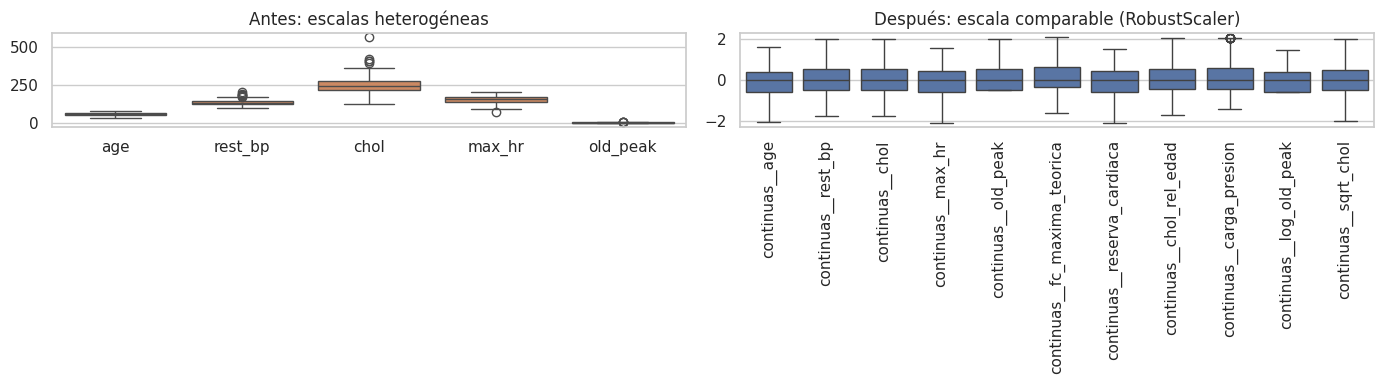

,mean,std,min,max
continuas__age,-0.112,0.692,-2.077,1.615
continuas__rest_bp,0.031,0.832,-1.800,2.000
continuas__chol,0.062,0.730,-1.802,2.006
continuas__max_hr,-0.110,0.713,-2.103,1.540
continuas__old_peak,0.114,0.663,-0.500,2.000
continuas__fc_maxima_teorica,0.112,0.692,-1.615,2.077
continuas__reserva_cardiaca,-0.179,0.775,-2.099,1.492
continuas__chol_rel_edad,0.063,0.749,-1.743,2.031
continuas__carga_presion,0.155,0.813,-1.421,2.056
continuas__log_old_peak,-0.031,0.531,-0.615,1.451


In [26]:
columnas_continuas_proc = [c for c in X_train_proc.columns if c.startswith("continuas__")]
resumen_escala = X_train_proc[columnas_continuas_proc].describe().T[["mean", "std", "min", "max"]]

fig, ejes = plt.subplots(1, 2, figsize=(14, 4))
sns.boxplot(data=X_train[CONTINUAS[:5]], ax=ejes[0], color="#DD8452")
ejes[0].set_title("Antes: escalas heterogéneas")
sns.boxplot(data=X_train_proc[columnas_continuas_proc], ax=ejes[1], color="#4C72B0")
ejes[1].set_title("Después: escala comparable (RobustScaler)")
ejes[1].tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

resumen_escala.round(3)

### 13.2 Prueba de no-fuga de datos

Si el pipeline no filtrara información, ajustarlo con `train` y aplicarlo a `test` debe
producir en `test` estadísticos **cercanos pero no idénticos** a los de `train`. Un
`test` perfectamente centrado en 0 sería síntoma de que se ajustó con todos los datos.

In [27]:
comparacion_split = pd.DataFrame(
    {
        "media_train": X_train_proc[columnas_continuas_proc].mean(),
        "media_test": X_test_proc[columnas_continuas_proc].mean(),
    }
).round(3)
comparacion_split["diferencia"] = (
    comparacion_split["media_train"] - comparacion_split["media_test"]
).abs()
comparacion_split.sort_values("diferencia", ascending=False).head(8)

,media_train,media_test,diferencia
continuas__sqrt_chol,0.031,-0.191,0.222
continuas__chol,0.062,-0.156,0.218
continuas__rest_bp,0.031,0.211,0.180
continuas__chol_rel_edad,0.063,-0.094,0.157
continuas__carga_presion,0.155,0.295,0.140
continuas__old_peak,0.114,0.246,0.132
continuas__reserva_cardiaca,-0.179,-0.267,0.088
continuas__log_old_peak,-0.031,0.031,0.062


## 14. Prueba de extremo a extremo con un modelo *baseline*

El objetivo **no** es optimizar el modelo (eso corresponde a la etapa 5), sino demostrar
que el pipeline se acopla a un estimador y que la validación cruzada re-ajusta el
preprocesamiento en cada *fold* — la única forma correcta de estimar el desempeño.

In [28]:
pipeline_modelo = Pipeline(
    steps=[
        ("features", pipeline_features),
        ("modelo", LogisticRegression(max_iter=2000, random_state=SEMILLA)),
    ]
)

validacion = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
puntajes = cross_val_score(
    pipeline_modelo,
    X_train[ATRIBUTOS_SELECCIONADOS],
    y_train,
    cv=validacion,
    scoring="roc_auc",
)

print(f"ROC-AUC (5-fold, sólo train): {puntajes.mean():.4f} ± {puntajes.std():.4f}")
print(f"Folds: {np.round(puntajes, 4).tolist()}")

pipeline_modelo.fit(X_train[ATRIBUTOS_SELECCIONADOS], y_train)
probabilidades = pipeline_modelo.predict_proba(X_test[ATRIBUTOS_SELECCIONADOS])[:, 1]
print(f"ROC-AUC en test (referencia) : {roc_auc_score(y_test, probabilidades):.4f}")
print(
    f"Exactitud en test           : {pipeline_modelo.score(X_test[ATRIBUTOS_SELECCIONADOS], y_test):.4f}"
)

ROC-AUC (5-fold, sólo train): 0.8859 ± 0.0371
Folds: [0.9164, 0.9327, 0.8514, 0.8934, 0.8357]
ROC-AUC en test (referencia) : 0.9545
Exactitud en test           : 0.8852


## 15. Persistencia de los artefactos

Se guardan dos cosas distintas y complementarias:

1. **El pipeline ajustado** (`.joblib`): es el artefacto que se despliega. Garantiza que
   en inferencia se apliquen exactamente las mismas transformaciones con los mismos
   parámetros aprendidos en `train`.
2. **Los datasets procesados** (`.parquet`): entrada directa de la etapa de modelado.

> **Nota para producción.** `RecortadorAtipicos` y `MarcadorAtipicos` están definidos en
> este notebook, así que el `.joblib` sólo puede deserializarse donde esas clases existan.
> Antes de desplegar deben moverse a `src/pipelines/feature_pipeline/` e importarse desde
> allí, tanto en el notebook como en el servicio de inferencia. Por eso ni los `.parquet`
> (carpeta `data/`, ya ignorada por `.gitignore`) ni el `.joblib` se versionan: son
> artefactos reproducibles al re-ejecutar este notebook.

In [29]:
ARCHIVO_PIPELINE = RUTA_MODELOS / "pipeline_feature_engineering.joblib"
joblib.dump(pipeline_features, ARCHIVO_PIPELINE)

train_procesado = X_train_proc.copy()
train_procesado[OBJETIVO] = y_train.to_numpy()
test_procesado = X_test_proc.copy()
test_procesado[OBJETIVO] = y_test.to_numpy()

train_procesado.to_parquet(RUTA_MODEL_INPUT / "corazon_train.parquet", index=False)
test_procesado.to_parquet(RUTA_MODEL_INPUT / "corazon_test.parquet", index=False)

for archivo in (
    ARCHIVO_PIPELINE,
    RUTA_MODEL_INPUT / "corazon_train.parquet",
    RUTA_MODEL_INPUT / "corazon_test.parquet",
):
    print(f"{archivo.relative_to(RUTA_RAIZ)}  ({archivo.stat().st_size / 1024:.1f} KB)")

models/pipeline_feature_engineering.joblib  (14.9 KB)
data/05_model_input/corazon_train.parquet  (41.9 KB)
data/05_model_input/corazon_test.parquet  (33.7 KB)


### 15.1 Verificación de reproducibilidad

Se recarga el pipeline serializado y se comprueba que reproduce exactamente la misma
salida — condición indispensable para que sirva en producción.

In [30]:
pipeline_recargado = joblib.load(ARCHIVO_PIPELINE)
reproducido = pipeline_recargado.transform(X_test[ATRIBUTOS_SELECCIONADOS])

identico = np.allclose(reproducido.to_numpy(), X_test_proc.to_numpy())
print(f"El pipeline recargado reproduce la misma salida: {identico}")

# Simulación de inferencia con un único paciente nuevo
paciente_nuevo = X_test[ATRIBUTOS_SELECCIONADOS].iloc[[0]]
print(
    f"\nInferencia sobre 1 paciente -> {pipeline_recargado.transform(paciente_nuevo).shape[1]} atributos"
)

El pipeline recargado reproduce la misma salida: True

Inferencia sobre 1 paciente -> 42 atributos


## 16. Conclusiones

| Etapa solicitada | Implementación |
|---|---|
| **1. Limpieza** | Normalización de texto, validación contra dominios y rangos fisiológicos, eliminación de filas sin *target*, de filas con más del 50 % de faltantes y de **duplicados exactos**. Imputación por mediana/moda **dentro del pipeline**. |
| **1b. Atípicos** | Estrategia *marcar y acotar*: `MarcadorAtipicos` (indicadores binarios) + `RecortadorAtipicos` (winsorizing con límites de Tukey aprendidos en `train`). No se elimina ningún paciente. |
| **2. Selección de atributos** | Descarte por cuasi-constancia (>99 %) e información mutua ≈ 0, evaluado sólo sobre `train`, más verificación de duplicados emergentes. |
| **3. Ingeniería de atributos** | 7 atributos derivados (razones clínicas, `log`, `√`, indicador binario) vía `FunctionTransformer` + discretización en cuartiles con `KBinsDiscretizer`. |
| **4. Escalado** | `RobustScaler`, elegido tras comparar contra `StandardScaler` y `MinMaxScaler`. |
| **5. Encoding** | `OneHotEncoder` para nominales, `OrdinalEncoder` con orden explícito para `slope` y `ca`. |
| **Ensamblaje** | 6 sub-`Pipeline` unidos por un `ColumnTransformer`, envueltos en un `Pipeline` de dos pasos. |

**Resultado:** un único artefacto reutilizable (`models/pipeline_feature_engineering.joblib`)
y los conjuntos `train`/`test` procesados en `data/05_model_input/`.

**Siguiente etapa (5 - Modelos):** cargar `pipeline_feature_engineering.joblib`,
encadenarlo con distintos estimadores y optimizar hiperparámetros con `GridSearchCV`
sobre el pipeline completo — incluidos los del preprocesamiento (`n_bins` de la
discretización, `factor` del recorte de atípicos, `strategy` de la imputación).